# Convolutional Neural Networks

## Google Colab Setup _(use for Google Colab env)_

In [ ]:
!git clone https://github.com/druidmentalized/MIWTutorials.git
import sys
sys.path.append('/content/MIWTutorials/Project4')

## Libraries

In [1]:
from data import load_data, get_augmentor
from models import build_model_a, build_model_b, build_model_c
from utils import plot_history, evaluate_model, show_confusion_matrix, show_misclassified

import tensorflow as tf

## General Setup

In [2]:
RS = 1337
LABELS = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

markers = {
    "a": "Model A",
    "b": "Model B",
    "c": "Model C",
}

print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Data

In [3]:
(x_train, y_train), (x_val, y_val), (x_test, y_test) = load_data(RS)
augmentor = get_augmentor(x_train)

## 2. CNN Model

### 2.1 Model A _(1 conv. block)_

In [4]:
model_a = build_model_a()

2026-05-11 01:26:43.044538: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-05-11 01:26:43.044616: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-05-11 01:26:43.044628: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
I0000 00:00:1778455603.044943 13109999 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1778455603.045218 13109999 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


### 2.2 Model B (n=3 conv. blocks)

In [5]:
model_b = build_model_b()

### Model C _(n=4 conv. blocks + batch normalization)_

In [6]:
model_c = build_model_c()

## 3. Training

### 3.1 Model A

In [7]:
model_a.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_a = model_a.fit(
    augmentor.flow(x_train, y_train, batch_size=64),
    epochs=30,
    verbose='auto',
    validation_data=(x_val, y_val)
)

Epoch 1/30


2026-05-11 01:27:01.510325: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.3291 - loss: 1.8349 - val_accuracy: 0.4464 - val_loss: 1.5038
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.4265 - loss: 1.6068 - val_accuracy: 0.5234 - val_loss: 1.3490
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.4263 - loss: 1.6317 - val_accuracy: 0.5206 - val_loss: 1.3952
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.4349 - loss: 1.6366 - val_accuracy: 0.5163 - val_loss: 1.3662
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.4367 - loss: 1.6181 - val_accuracy: 0.5174 - val_loss: 1.4090
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.4402 - loss: 1.5975 - val_accuracy: 0.5433 - val_loss: 1.2914
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.4458 - loss: 1.5947 - val_accuracy: 0.4689 - val_loss: 1.4692
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.4329 - loss: 1.6794 - val_accuracy: 0.47

### 3.2 Model B

In [8]:
model_b.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_b = model_b.fit(
    augmentor.flow(x_train, y_train, batch_size=64),
    epochs=30,
    verbose='auto',
    validation_data=(x_val, y_val)
)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.2353 - loss: 2.0282 - val_accuracy: 0.3512 - val_loss: 1.7861
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.3389 - loss: 1.7902 - val_accuracy: 0.4259 - val_loss: 1.5568
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.3787 - loss: 1.6860 - val_accuracy: 0.4447 - val_loss: 1.5115
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.3926 - loss: 1.7306 - val_accuracy: 0.4712 - val_loss: 1.4626
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.3816 - loss: 1.8147 - val_accuracy: 0.4656 - val_loss: 1.5039
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.3762 - loss: 1.8891 - val_accuracy: 0.3832 - val_loss: 1.6601
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.3963 - loss: 1.7923 - val_accuracy: 0.4280 - val_loss: 1.6168
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.3895 - loss: 1.8979 - 

### 3.3 Model C

In [9]:
model_c.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_c = model_c.fit(
    augmentor.flow(x_train, y_train, batch_size=64),
    epochs=30,
    verbose='auto',
    validation_data=(x_val, y_val)
)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 33s 75ms/step - accuracy: 0.1711 - loss: 3.8126 - val_accuracy: 0.2349 - val_loss: 2.0476
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 27s 71ms/step - accuracy: 0.2341 - loss: 2.9854 - val_accuracy: 0.2616 - val_loss: 3.8191
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 27s 72ms/step - accuracy: 0.2888 - loss: 2.2275 - val_accuracy: 0.3669 - val_loss: 1.7260
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 27s 71ms/step - accuracy: 0.3572 - loss: 1.7956 - val_accuracy: 0.4407 - val_loss: 1.5342
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 27s 71ms/step - accuracy: 0.4141 - loss: 1.6052 - val_accuracy: 0.3358 - val_loss: 2.2027
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 27s 71ms/step - accuracy: 0.4526 - loss: 1.5081 - val_accuracy: 0.5158 - val_loss: 1.4468
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 27s 72ms/step - accuracy: 0.4903 - loss: 1.4234 - val_accuracy: 0.5017 - val_loss: 1.4070
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 27s 72ms/step - accuracy: 0.5182 - loss: 1.3541 - 

## 4. Evaluation

### 4.1 Plot

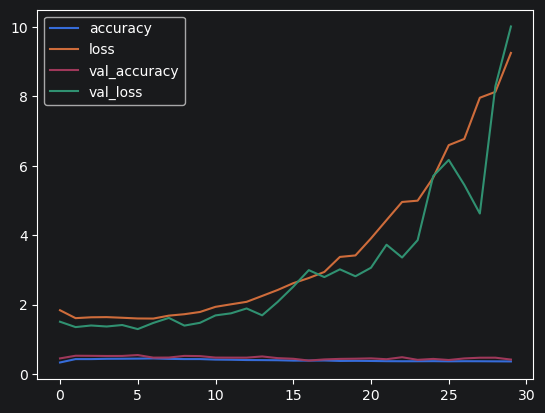

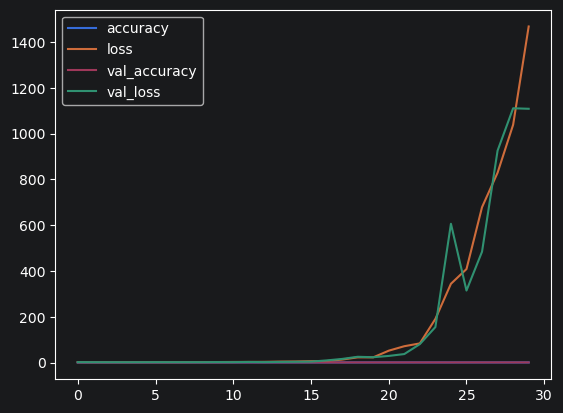

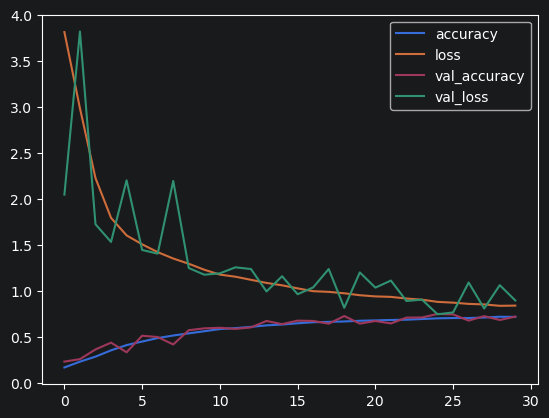

In [10]:
plot_history(history_a, markers["a"])
plot_history(history_b, markers["b"])
plot_history(history_c, markers["c"])

### 4.2 Evaluate

In [11]:
evaluate_model(model_a, x_test, y_test, markers["a"])
evaluate_model(model_b, x_test, y_test, markers["b"])
evaluate_model(model_c, x_test, y_test, markers["c"])

563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4154 - loss: 9.7617
Test loss of Model A: 9.761739730834961
Test accuracy Model A: 0.41544443368911743
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5132 - loss: 1114.9705
Test loss of Model B: 1114.970458984375
Test accuracy Model B: 0.5132222175598145
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7231 - loss: 0.8978
Test loss of Model C: 0.8978464007377625
Test accuracy Model C: 0.7230555415153503


### 4.3 Confusion Matrix

563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 936us/step


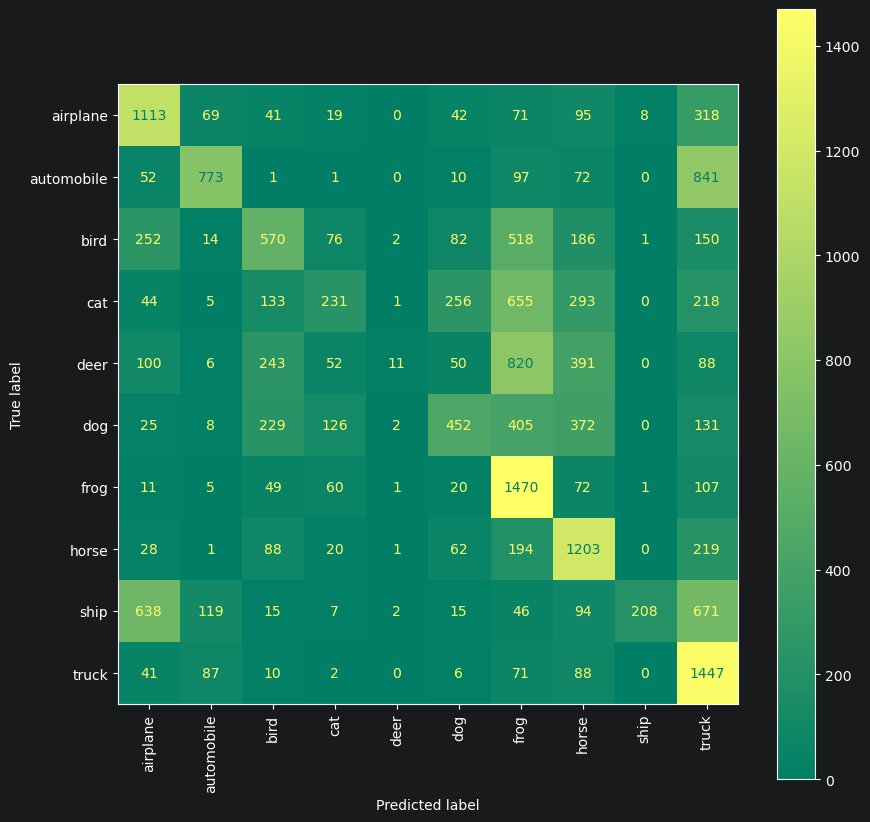

563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


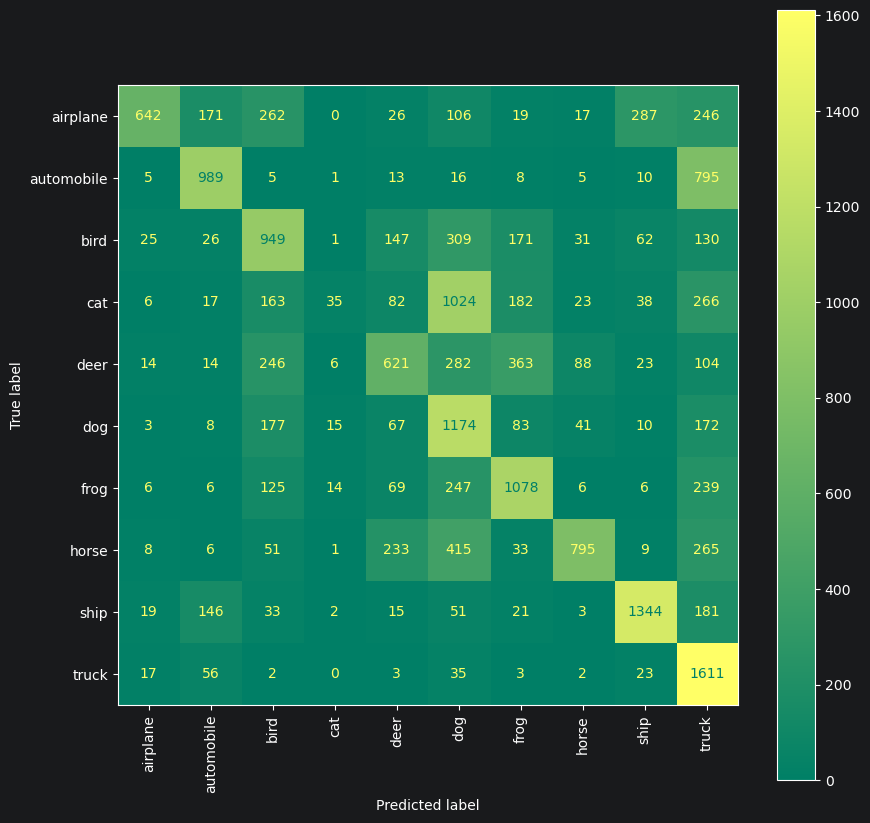

563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


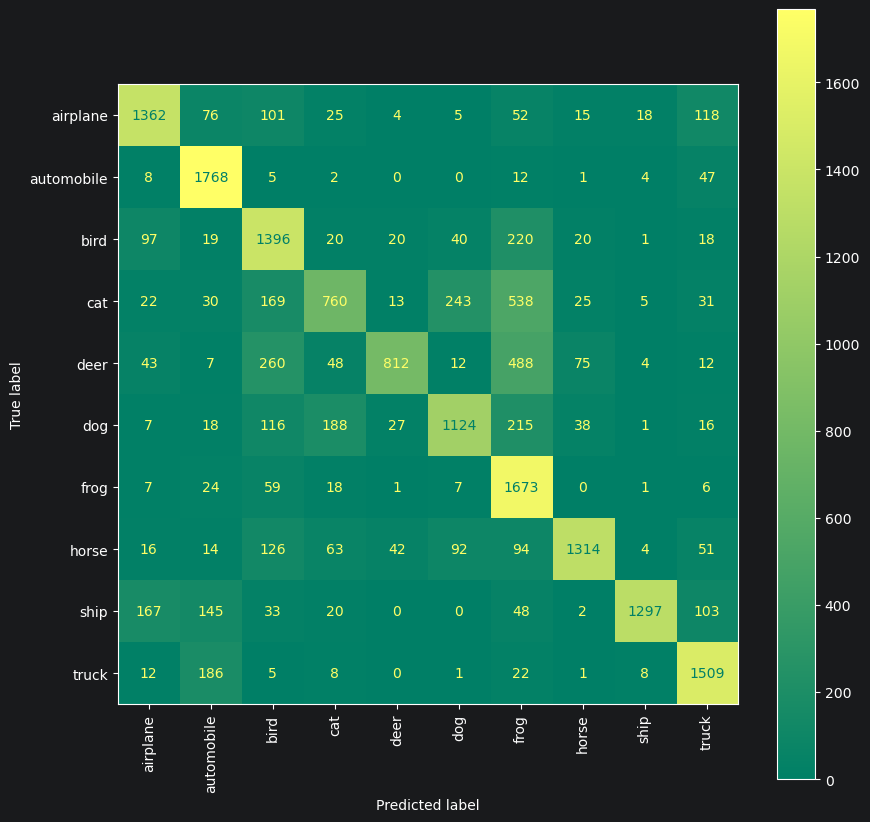

In [12]:
show_confusion_matrix(model_a, x_test, y_test, LABELS, markers["a"])
show_confusion_matrix(model_b, x_test, y_test, LABELS, markers["b"])
show_confusion_matrix(model_c, x_test, y_test, LABELS, markers["c"])

## 5. Analysis

563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


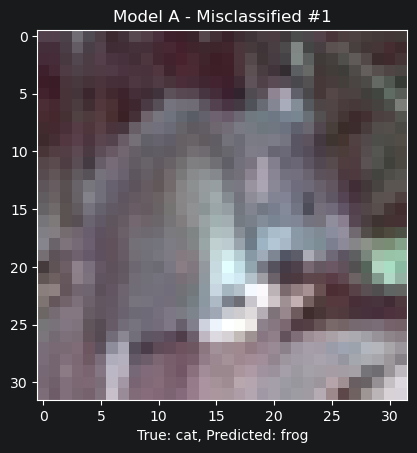

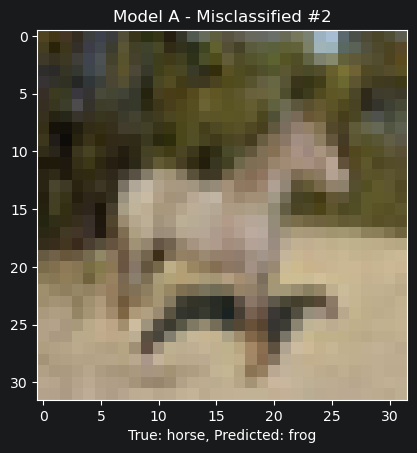

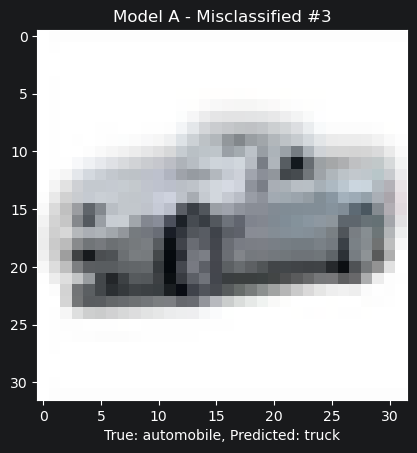

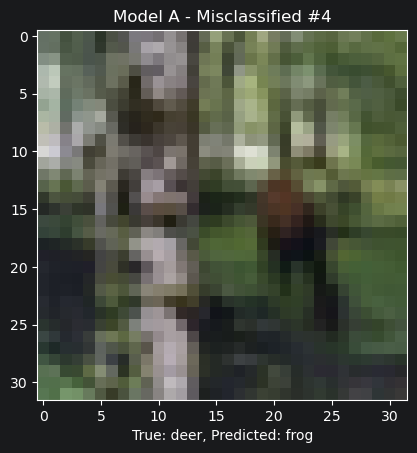

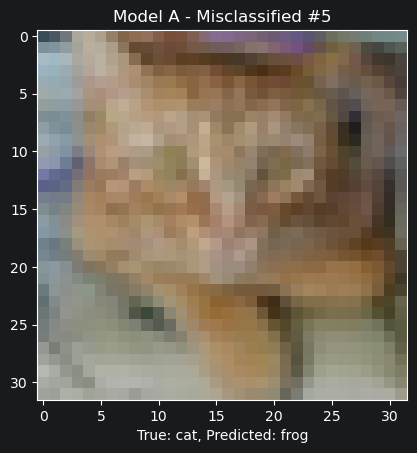

563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


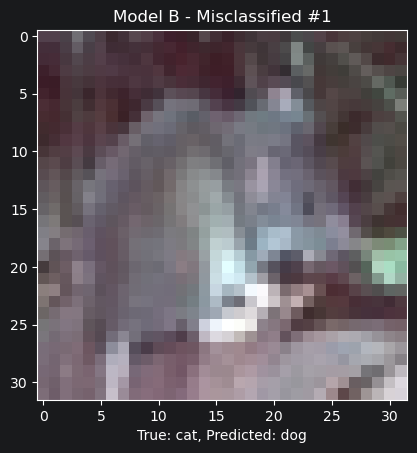

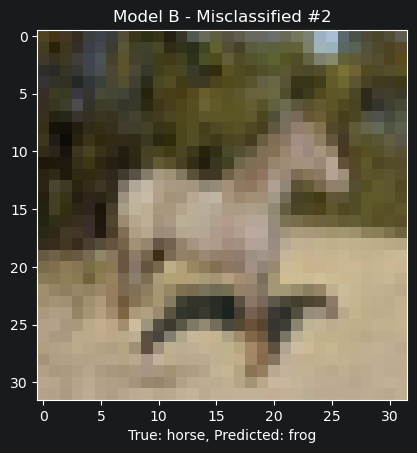

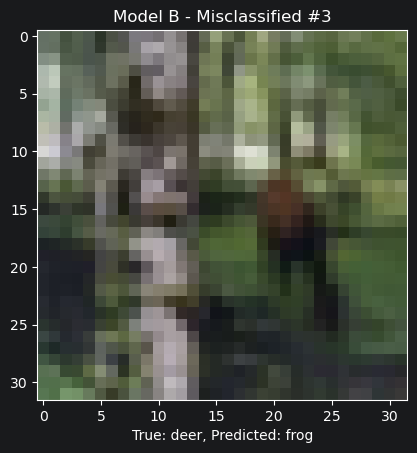

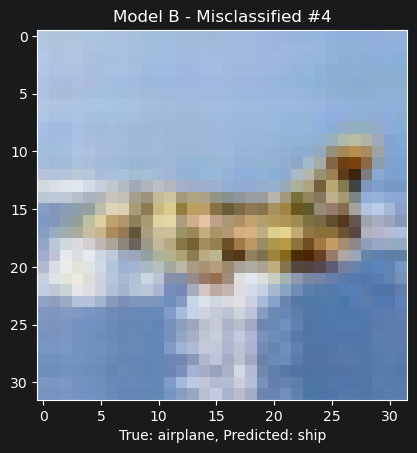

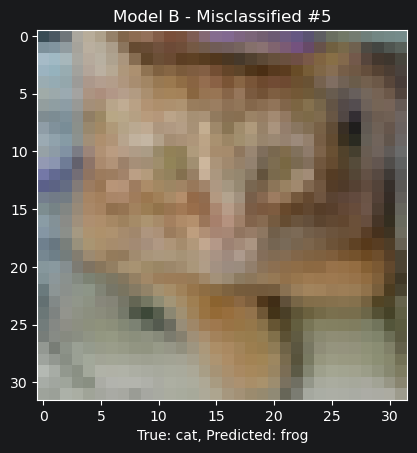

563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


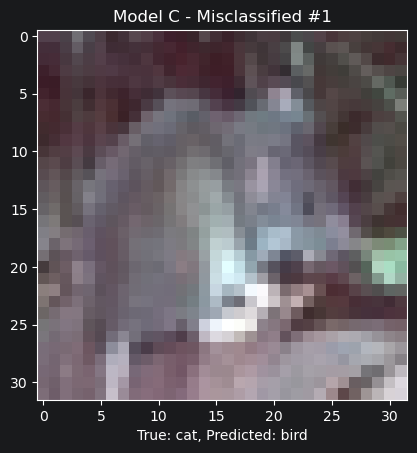

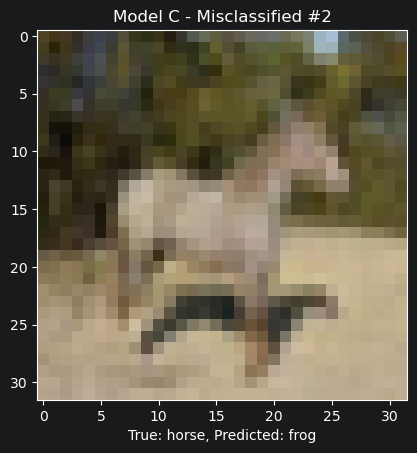

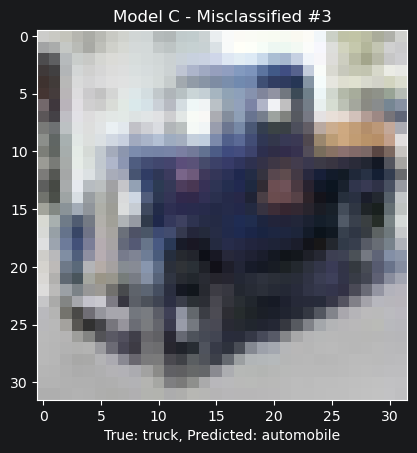

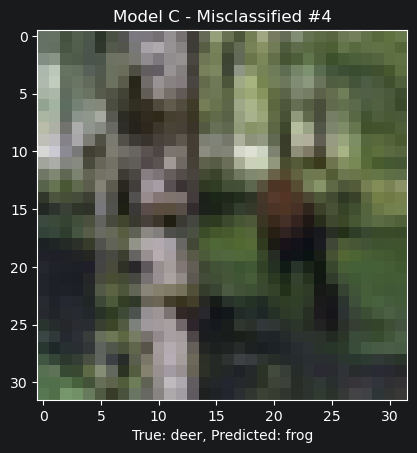

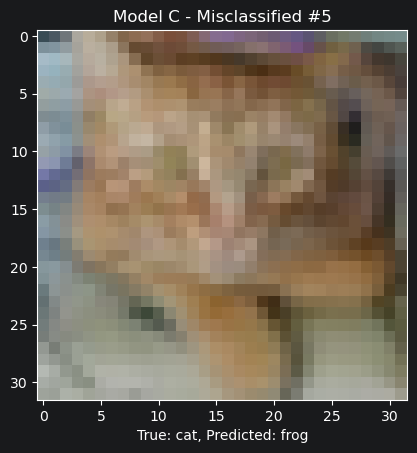

In [13]:
show_misclassified(model_a, x_test, y_test, LABELS, markers["a"])
show_misclassified(model_b, x_test, y_test, LABELS, markers["b"])
show_misclassified(model_c, x_test, y_test, LABELS, markers["c"])

## 6. Conclusions